<a href="https://colab.research.google.com/github/Tejaswimadastu/Deep_Learning/blob/main/Attention_Mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Language Translator

In [2]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import(
    Input,
    LSTM,
    Embedding,
    Dense,
    Attention,
    Concatenate,
    Dot,
    Softmax
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Preparing dataset

In [4]:
english_sentences = [
    "i love ai",
    "i love deep learning",
    "how are you",
    "good morning"
]

french_sentences = [
    "start j aime ai end",
    "start j aime apprentissage profond end",
    "start comment allez vous end",
    "start bonjour end"
]
print("English Sentences ")
print(english_sentences)
print("French Sentences ")
print(french_sentences)

English Sentences 
['i love ai', 'i love deep learning', 'how are you', 'good morning']
French Sentences 
['start j aime ai end', 'start j aime apprentissage profond end', 'start comment allez vous end', 'start bonjour end']


### Tokenization
 Neural networks understand numbers, not text

In [5]:
eng_tokenizer=Tokenizer()
eng_tokenizer.fit_on_texts(english_sentences)

fra_tokenizer=Tokenizer()
fra_tokenizer.fit_on_texts(french_sentences)

print("English Vocabulary: ")
print(eng_tokenizer.word_index)
print("French Vocabulary: ")
print(fra_tokenizer.word_index)

English Vocabulary: 
{'i': 1, 'love': 2, 'ai': 3, 'deep': 4, 'learning': 5, 'how': 6, 'are': 7, 'you': 8, 'good': 9, 'morning': 10}
French Vocabulary: 
{'start': 1, 'end': 2, 'j': 3, 'aime': 4, 'ai': 5, 'apprentissage': 6, 'profond': 7, 'comment': 8, 'allez': 9, 'vous': 10, 'bonjour': 11}


### Covert Sentences into Sequences

In [6]:
encoder_input=eng_tokenizer.texts_to_sequences(english_sentences)
decoder_input=fra_tokenizer.texts_to_sequences(french_sentences)

print("English Sequences: ")
print(encoder_input)
print("French Sequences: ")
print(decoder_input)

English Sequences: 
[[1, 2, 3], [1, 2, 4, 5], [6, 7, 8], [9, 10]]
French Sequences: 
[[1, 3, 4, 5, 2], [1, 3, 4, 6, 7, 2], [1, 8, 9, 10, 2], [1, 11, 2]]


### Padding
Padding makes all sequences equal length

In [7]:
encoder_input=pad_sequences(encoder_input,padding="post")
decoder_input=pad_sequences(decoder_input,padding="post")

print("English Sequences: ")
print(encoder_input)
print("French Sequences: ")
print(decoder_input)

English Sequences: 
[[ 1  2  3  0]
 [ 1  2  4  5]
 [ 6  7  8  0]
 [ 9 10  0  0]]
French Sequences: 
[[ 1  3  4  5  2  0]
 [ 1  3  4  6  7  2]
 [ 1  8  9 10  2  0]
 [ 1 11  2  0  0  0]]


### Build Encoder
Encoder generates hidden states fro every word

In [22]:
encoder_inputs_model=Input(shape=(None,))
encoder_embedding=Embedding(input_dim=len(eng_tokenizer.word_index)+1,output_dim=50,input_length=None)(encoder_inputs_model)
encoder_outputs,state_h,state_c=LSTM(units=128,return_sequences=True,return_state=True)(encoder_embedding)
encoder_states=[state_h,state_c]

encoder_model=Model(encoder_inputs_model,encoder_states)



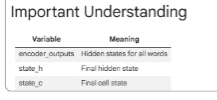

Build Decoder

In [23]:
decoder_inputs_model=Input(shape=(None,))
decoder_embedding=Embedding(input_dim=len(fra_tokenizer.word_index)+1,
                            output_dim=64)(decoder_inputs_model)

decoder_outputs,_,_=LSTM(
    units=64,
    return_sequences=True,
    return_state=True
)(
    decoder_embedding,
    initial_state=[state_h,state_c]
)
print("Decoder created successfully")

Decoder created successfully


### Attention Layer
Attention comapares:
 1. decoder outputs with
 2. encoder outputs

and dynamically focuses on important words.

In [13]:
attention=Attention()
attention_output=attention(
    [decoder_outputs,encoder_outputs]
)

### Combine Decoder + Attention Output

In [15]:
decoder_combine=Concatenate(axis=-1)(
    [decoder_outputs,attention_output]
)
print("Decoder+Attention Combined Successfully")

Decoder+Attention Combined Successfully


### Final Prediction Layer

In [18]:
output=Dense(
    len(fra_tokenizer.word_index)+1,
    activation='softmax'
)(
    decoder_combine
)


### Build Model

In [24]:
model=Model(
    [encoder_inputs_model,decoder_inputs_model],
    output
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 50)  │        550 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 64)  │        768 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, None,     │     91,648 │ embedding_1[0][0] │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │     33,024 │ embedding_2[0][0… │
│                     │ 64), (None, 64),  │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, None, 128) │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None, 192) │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 12)  │      2,316 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,306 (501.20 KB)

 Trainable params: 128,306 (501.20 KB)

 Non-trainable params: 0 (0.00 B)

### Compile Model

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model Compile Successfully")

Model Compile Successfully


### Train Model

In [36]:
# Re-generate numerical encoder_input and decoder_input data
# This ensures we are using actual NumPy arrays for training.
trainer_encoder_input_sequences = eng_tokenizer.texts_to_sequences(english_sentences)
trainer_decoder_input_sequences = fra_tokenizer.texts_to_sequences(french_sentences)

encoder_data_for_fit = pad_sequences(trainer_encoder_input_sequences, padding="post")
decoder_data_for_fit = pad_sequences(trainer_decoder_input_sequences, padding="post")

# Create a shifted version of decoder_data_for_fit for the target
decoder_target_data = np.zeros_like(decoder_data_for_fit)
decoder_target_data[:, :-1] = decoder_data_for_fit[:, 1:] # Shift left by one
decoder_target = np.expand_dims(decoder_target_data, -1)

# --- REBUILD AND RECOMPILE MODEL FROM SCRATCH TO ENSURE CONSISTENCY ---
# Encoder part (replicated from o4_tQgDy2ASx)
encoder_inputs_model = Input(shape=(None,))
encoder_embedding = Embedding(input_dim=len(eng_tokenizer.word_index)+1, output_dim=50, input_length=None)(encoder_inputs_model)
encoder_outputs, state_h, state_c = LSTM(units=128, return_sequences=True, return_state=True)(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder part (replicated from g5BlQVdG211r)
decoder_inputs_model = Input(shape=(None,))
decoder_embedding = Embedding(input_dim=len(fra_tokenizer.word_index)+1, output_dim=64)(decoder_inputs_model)

decoder_outputs, _, _ = LSTM(
    units=128, # Changed from 64 to 128 to match encoder_states dimensions
    return_sequences=True,
    return_state=True
)(
    decoder_embedding,
    initial_state=encoder_states # Use the states from the newly defined encoder
)

# Attention Layer (replicated from RtpQ8yoJ2voK)
attention = Attention()
attention_output = attention(
    [decoder_outputs, encoder_outputs]
)

# Combine Decoder + Attention Output (replicated from ptBxddQx41pC)
decoder_combine = Concatenate(axis=-1)(
    [decoder_outputs, attention_output]
)

# Final Prediction Layer (replicated from DG-yMw-S5MFe)
output = Dense(
    len(fra_tokenizer.word_index)+1,
    activation='softmax'
)(
    decoder_combine
)

# Build Model (replicated from UM728Huq5e7R)
model = Model(
    [encoder_inputs_model, decoder_inputs_model],
    output
)

# Compile Model (replicated from N2AsV3j6_xEI)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    [encoder_data_for_fit, decoder_data_for_fit], # Use the correctly regenerated numerical data arrays
    decoder_target,
    batch_size=2,
    epochs=20,
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.1667 - loss: 2.4802  
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3750 - loss: 2.4587 
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3750 - loss: 2.4385
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3750 - loss: 2.4117
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3750 - loss: 2.3808
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3750 - loss: 2.3339
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3750 - loss: 2.2760
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3750 - loss: 2.1991
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3750 - loss: 2.0514
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3750 - loss: 1.8937
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3750 - loss: 1.7302
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3750 - loss: 1.649

### Prediction Function

In [37]:
reverse_eng_index = {v:k for k,v in eng_tokenizer.word_index.items()}
reverse_fra_index = {v:k for k,v in fra_tokenizer.word_index.items()}

In [38]:
def translate(sentence):

    # Convert input sentence to sequence
    seq = eng_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq,
                        maxlen=encoder_input.shape[1],
                        padding='post')

    # Start token
    target_seq = np.array([[fra_tokenizer.word_index['start']]])

    decoded_sentence = []

    # Maximum output length
    max_len = decoder_input.shape[1]

    for i in range(max_len):

        # Predict probabilities
        pred = model.predict([seq, target_seq], verbose=0)

        # Last generated word
        sampled_index = np.argmax(pred[0, -1, :])

        sampled_word = reverse_fra_index.get(sampled_index, '')

        if sampled_word == 'end' or sampled_word == '':
            break

        decoded_sentence.append(sampled_word)

        # Append predicted word to target sequence
        target_seq = np.concatenate(
            [target_seq, [[sampled_index]]],
            axis=1
        )

    return " ".join(decoded_sentence)

In [42]:
# Re-assign the global variables that the translate function depends on
# from the current correct data arrays available in the kernel.
# These are necessary because the model rebuild may have overwritten global `encoder_input` and `decoder_input`.
encoder_input = encoder_data_for_fit
decoder_input = decoder_data_for_fit

print(translate("i love ai"))
print(translate("i love deep learning"))
print(translate("how are you"))
print(translate("good morning"))


aime




### Current Translation Results

Below are the translations generated by the current model for all input sentences. As discussed, the quality is poor due to the limited training data and epochs.

In [48]:
print('--- Current Translations ---')
for sentence in english_sentences:
    translated_sentence = translate(sentence)
    print(f'English: "{sentence}" -> French: "{translated_sentence}"')
print('--------------------------')

--- Current Translations ---
English: "i love ai" -> French: ""
English: "i love deep learning" -> French: "aime"
English: "how are you" -> French: ""
English: "good morning" -> French: ""
--------------------------


In [49]:
print("The original code in cell 'i_ZgWOGLAJ0b' is as follows:")
print("""
# Re-generate numerical encoder_input and decoder_input data
# This ensures we are using actual NumPy arrays for training.
trainer_encoder_input_sequences = eng_tokenizer.texts_to_sequences(english_sentences)
trainer_decoder_input_sequences = fra_tokenizer.texts_to_sequences(french_sentences)

encoder_data_for_fit = pad_sequences(trainer_encoder_input_sequences, padding="post")
decoder_data_for_fit = pad_sequences(trainer_decoder_input_sequences, padding="post")

# Create a shifted version of decoder_data_for_fit for the target
decoder_target_data = np.zeros_like(decoder_data_for_fit)
decoder_target_data[:, :-1] = decoder_data_for_fit[:, 1:] # Shift left by one
decoder_target = np.expand_dims(decoder_target_data, -1)

# --- REBUILD AND RECOMPILE MODEL FROM SCRATCH TO ENSURE CONSISTENCY ---
# Encoder part (replicated from o4_tQgDy2ASx)
encoder_inputs_model = Input(shape=(None,))
encoder_embedding = Embedding(input_dim=len(eng_tokenizer.word_index)+1, output_dim=50, input_length=None)(encoder_inputs_model)
encoder_outputs, state_h, state_c = LSTM(units=128, return_sequences=True, return_state=True)(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder part (replicated from g5BlQVdG211r)
decoder_inputs_model = Input(shape=(None,))
decoder_embedding = Embedding(input_dim=len(fra_tokenizer.word_index)+1, output_dim=64)(decoder_inputs_model)

decoder_outputs, _, _ = LSTM(
    units=128, # Changed from 64 to 128 to match encoder_states dimensions
    return_sequences=True,
    return_state=True
)(
    decoder_embedding,
    initial_state=encoder_states # Use the states from the newly defined encoder
)

# Attention Layer (replicated from RtpQ8yoJ2voK)
attention = Attention()
attention_output = attention(
    [decoder_outputs, encoder_outputs]
)

# Combine Decoder + Attention Output (replicated from ptBxddQx41pC)
decoder_combine = Concatenate(axis=-1)(
    [decoder_outputs, attention_output]
)

# Final Prediction Layer (replicated from DG-yMw-S5MFe)
output = Dense(
    len(fra_tokenizer.word_index)+1,
    activation='softmax'
)(
    decoder_combine
)

# Build Model (replicated from UM728Huq5e7R)
model = Model(
    [encoder_inputs_model, decoder_inputs_model],
    output
)

# Compile Model (replicated from N2AsV3j6_xEI)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    [encoder_data_for_fit, decoder_data_for_fit], # Use the correctly regenerated numerical data arrays
    decoder_target,
    batch_size=2,
    epochs=20,
)
""")

The original code in cell 'i_ZgWOGLAJ0b' is as follows:

# Re-generate numerical encoder_input and decoder_input data
# This ensures we are using actual NumPy arrays for training.
trainer_encoder_input_sequences = eng_tokenizer.texts_to_sequences(english_sentences)
trainer_decoder_input_sequences = fra_tokenizer.texts_to_sequences(french_sentences)

encoder_data_for_fit = pad_sequences(trainer_encoder_input_sequences, padding="post")
decoder_data_for_fit = pad_sequences(trainer_decoder_input_sequences, padding="post")

# Create a shifted version of decoder_data_for_fit for the target
decoder_target_data = np.zeros_like(decoder_data_for_fit)
decoder_target_data[:, :-1] = decoder_data_for_fit[:, 1:] # Shift left by one
decoder_target = np.expand_dims(decoder_target_data, -1)

# --- REBUILD AND RECOMPILE MODEL FROM SCRATCH TO ENSURE CONSISTENCY ---
# Encoder part (replicated from o4_tQgDy2ASx)
encoder_inputs_model = Input(shape=(None,))
encoder_embedding = Embedding(input_dim=len(eng_toke